### Stochastic interpolant demo with **equivariant OT**: uniform angles → 1D XY chain

A minimal model for 1D classical XY chains using an interpolant that
pairs base and target with the **Z₂ × U(1) equivariant-OT coupling**.

- `load_mc_data` — build the target dataset (XY-chain Monte Carlo samples).
- `sample_base`  — the prior sampler `p₀`: i.i.d. uniform angles on `(-π, π]`.
- `make_model`   — an `xyEESI` wrapping two `XYChainGNN`s (drift + score).
- `xy_step` / `train` — one coupled step / the full loop. The coupling
  (`eesi.ot.xy_ot_couple`) runs under `no_grad` and just re-pairs the batch before
  `model.loss`, so nothing about the interpolant changes.

The coupling has two independent layers, toggled per call: `align` (OT over the
symmetry group Z₂ × U(1)), `batch` (minibatch OT over the batch), and `reflect`
(include the Z₂ reflection, vs. U(1) only). See `eesi/ot.py`.

### 0. Imports & environment

In [9]:
# --- imports & environment ---
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.special import iv

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

# The new training hooks: dataset + sampler + model + coupled training step/loop.
from eesi.train.xy import load_mc_data, sample_base, make_model, xy_step, train
from eesi.ot import xy_transport_cost, xy_ot_couple

%matplotlib inline
torch.seed()
np.random.seed()
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:
def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x, J):              # E = J * sum_i cos(dtheta_i)
    return (J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()

### 1. Datasets & samplers

`load_mc_data` runs the Metropolis Monte Carlo sampler `eesi.datasets.xy.mcxy` and wraps the
angles onto `(-π, π]` which is the fixed **target** `p₁`. `sample_base` is the
**base** `p₀`: i.i.d. uniform angles, drawn each step. Both are Z₂ × U(1)
invariant, which is what makes the equivariant-OT coupling marginal-preserving.

We use a tiny `N = 10` chain to exercise the pipeline end-to-end.

In [3]:
N = 10           # chain length
J = 2.0          # ferromagnetic coupling of the target Boltzmann distribution

# --- target p_1: XY-chain Boltzmann samples (wrapped onto (-pi, pi]) ---
x1_all = load_mc_data(L=N, J=J, n_save=10_000,
                      n_eq=1_000_000, n_prod=1_000_000).to(device)
n_data = x1_all.shape[0]
print("target dataset:", tuple(x1_all.shape))

# --- base p_0: sample_base(B, N, device=..., dtype=...) ---
x0_demo = sample_base(4, N, device=device)
print("base sample   :", tuple(x0_demo.shape))

# Exact per-spin energy change (I_1/I_0 Bessel ratio) for reference.
dE = (N - 1) * (-J * (iv(1, J) / iv(0, J))) / N
print(f"exact energy  : {dE:+.4f}  (per spin)")

Equilibration complete, 94.3%  acceptance.
Equilibration complete, 94.2%  acceptance.
Mean energy: -1.2694011695960974
target dataset: (10000, 10)
base sample   : (4, 10)
exact energy  : -1.2560  (per spin)


### 2. Model & sampler setup (via `make_model`)

`make_model` returns an `xyEESI` wrapping two chain-length-independent
`XYChainGNN`s (drift `net_b` and score `net_s`); the interpolant `path`/`gamma`
schedules are passed straight through. Extra `xyEESI` kwargs (`d`,
`score_div_method`, …) go via `**kw`.

In [4]:
# Changing the batch size changes the x0/x1 coupling distribution and therefore
# the time-dependent marginals. So it's important to keep this constant across
# training and sampling.
batch_size = 256

# Model definition
model = make_model(
    n_neighbors=2, hidden=16, n_layers=8, edge_order=16, time_order=16,
    path="trig", gamma="sqrt", gamma_scale=0.25,
    score_div_method="exact",
).to(device)
print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

model.net_b.load_state_dict(torch.load('xy_b_N10_B256.pth',weights_only=True))
model.net_s.load_state_dict(torch.load('xy_s_N10_B256.pth',weights_only=True))


net_b params: 10752
net_s params: 10752


<All keys matched successfully>

### 3. Training with equivariant OT

`train` runs the coupled loop: each step draws a target minibatch and a fresh base
batch, applies `xy_ot_couple` (the flags below), and minimises the drift + score
losses. Setting `align`, `batch_ot`, `reflect` all `True` is the **full Z₂ × U(1)
equivariant-OT** coupling; the logged `transport` cost drops relative to random
pairing. Flip any flag off for the ablation arms (e.g. `align=False` = plain
minibatch OT, `reflect=False` = U(1) only).

In [75]:
model, hist = train(
    x1_all, model=model,
    steps=10_000, batch=batch_size, lr=1e-3,
    align=True, batch_ot=True, reflect=True,   # full equivariant-OT coupling
    device=str(device), seed=0, log_every=100,
)
hist_b, hist_s = map(np.asarray, zip(*hist))

  step     0  loss_b   -0.0006  loss_s    0.0013  transport   3.597  (  0.1s)
  step   100  loss_b   -0.8130  loss_s   -0.6793  transport   3.499  (  5.5s)
  step   200  loss_b   -2.1545  loss_s   -1.2587  transport   3.589  ( 10.7s)
  step   300  loss_b   -2.4135  loss_s   -0.9955  transport   3.616  ( 15.9s)
  step   400  loss_b   -2.5710  loss_s   -0.8928  transport   3.604  ( 20.9s)
  step   500  loss_b   -2.6633  loss_s   -0.1449  transport   3.665  ( 26.0s)
  step   600  loss_b   -2.6848  loss_s   -0.5943  transport   3.673  ( 31.1s)
  step   700  loss_b   -2.7871  loss_s   -1.5635  transport   3.604  ( 36.1s)
  step   800  loss_b   -2.8389  loss_s   -1.8430  transport   3.635  ( 41.2s)
  step   900  loss_b   -2.9128  loss_s   -2.0327  transport   3.568  ( 46.3s)
  step  1000  loss_b   -2.9554  loss_s   -2.1242  transport   3.574  ( 51.3s)
  step  1100  loss_b   -3.0121  loss_s   -1.8473  transport   3.598  ( 56.4s)
  step  1200  loss_b   -3.0694  loss_s   -2.3860  transport   3.

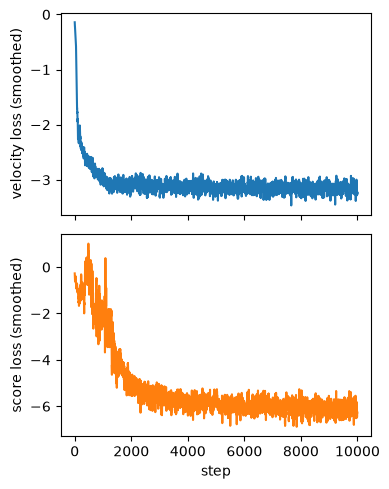

In [76]:
# Training curves (smoothed).
def smooth(v, k=10):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the built-in samplers (inherited unchanged from `EESI`):
`sample_ode` integrates the probability-flow ODE `dx/dt = b(t, x)`; `sample_sde`
integrates the reverse-time SDE using both `b` and `s`. We compare two physical
observables of generated vs. true configurations: the wrapped nearest-neighbour
angle difference Δθ and the per-chain energy `E = J Σ cos Δθ`.

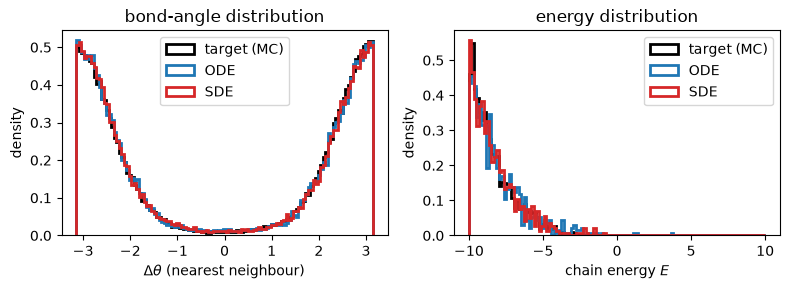

target (MC)   <E> = -12.4447   std(E) = 2.4397
ODE           <E> = -12.3193   std(E) = 2.4902
SDE           <E> = -12.3429   std(E) = 2.4820
Exact         <E> = -12.5599


In [14]:
torch.manual_seed(4)
n_gen = 5_000
x0 = sample_base(n_gen, N, device=device)
gen_ode = model.sample_ode(x0, n_steps=50)             # probability-flow ODE (drift only)
gen_sde = model.sample_sde(x0, n_steps=100, eps=0.25)    # reverse-time SDE (drift + score)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
bins = np.linspace(-np.pi, np.pi, 120)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[0].hist(dtheta(x), bins=bins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[0].set_xlabel(r"$\Delta\theta$ (nearest neighbour)"); ax[0].set_ylabel("density")
ax[0].set_title("bond-angle distribution"); ax[0].legend()

ebins = np.linspace(-N, N, 120)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[1].hist(chain_energy(x, J), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].set_xlabel("chain energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend()
plt.tight_layout()
plt.show()

for x, lbl in [(x1_all, "target (MC)"), (gen_ode, "ODE"), (gen_sde, "SDE")]:
    e = chain_energy(x, J)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")
print(f"{'Exact':12s}  <E> = {(N - 1) * (-J * (iv(1, J) / iv(0, J))):+.4f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways
(all inherited from `EESI`): `entropy_estimate_dot` (mean of $-b\cdot s$),
`entropy_estimate_div` (mean of $\nabla\!\cdot b$, score-free), and the running
ODE path integral from `sample_ode_entropy_traj`. Compared against the exact
$\Delta S = (N-1)\,[\log I_0(J) - J\,I_1(J)/I_0(J)]$.

entropy estimate (b·s)   : -4.9603 ± 0.2230
entropy estimate (div b) : -5.0335 ± 0.2314
entropy estimate (ODE path integral): -4.9887
exact entropy: -5.1440


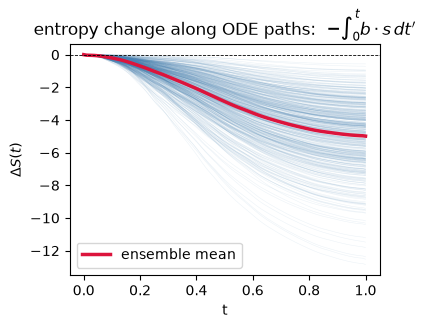

In [15]:
torch.manual_seed(2)
n_batches = 100
means_dot, means_div = [], []
for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(batch_size, N, device=device)
    x0, x1 = xy_ot_couple(x0, x1)
    means_dot.append(model.entropy_estimate_dot(x1, x0).mean().item())
    means_div.append(model.entropy_estimate_div(x1, x0).mean().detach().item())

print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.4f} ± {np.std(means_dot):.4f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.4f} ± {np.std(means_div):.4f}")

# Running entropy change along many ODE paths.
x0 = sample_base(5_000, N, device=device)
traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=100)
ts_c, ent_c = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (ODE path integral): {ent_c[-1].mean():+.4f}")
dS = (N - 1) * (np.log(iv(0, J)) - J * (iv(1, J) / iv(0, J)))
print(f"exact entropy: {dS:+.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

#### Save the models

In [82]:
torch.save(model.net_b.state_dict(), './xy_b_N10_B256.pth')
torch.save(model.net_s.state_dict(), './xy_s_N10_B256.pth')

### 6. Other Values of N

In [32]:
chain_lengths   = np.array([1,2,4,8,16,32,64])
energies        = np.zeros_like(chain_lengths,dtype=np.float64)
entropies       = np.zeros_like(chain_lengths,dtype=np.float64)

n_gen = 5_000

for i,chain_length in enumerate(chain_lengths):
    
    # sample base distribution and integrate, accumulating entropy
    x0 = sample_base(n_gen, chain_length, device=device)
    x1, ent = model.sample_ode_entropy(x0, n_steps=50)
    energies[i] = chain_energy(x1, J).mean()/float(chain_length)
    entropies[i] = ent.cpu().numpy().mean()/float(chain_length)

free_energies = energies - entropies


In [5]:
chain_lengths   = np.array([1,2,4,8,16,32,64])
energies = np.load("xy_ener.npy")
entropies = np.load("xy_entr.npy")
free_energies = energies - entropies

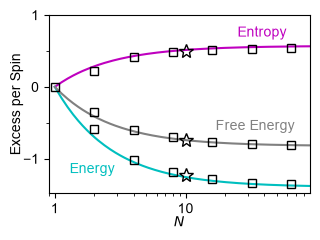

In [12]:
import matplotlib


fig,ax = plt.subplots(1,1,figsize=(3.3,2.5))

Nspace = np.linspace(1,2*np.amax(chain_lengths),1000)
ds = ((Nspace-1)/Nspace) * (np.log(iv(0,J))-J*(iv(1,J)/iv(0,J)))
de = ((Nspace-1)/Nspace) * (-J*(iv(1,J)/iv(0,J)))
df = de - ds
plt.plot(Nspace,-ds,'-m',mfc='none',label=r'$-\Delta \tilde{s}$',ms=5)
plt.plot(Nspace,de,'-c',mfc='none',label=r"$\Delta \tilde{u}$",ms=5)
plt.plot(Nspace,df,'-',color='gray',mfc='none',label=r"$\Delta \tilde{f}$",ms=5)



plt.plot(chain_lengths[1:],energies[1:],'ks',mfc='none')
plt.plot(chain_lengths[1:],-entropies[1:],'ks',mfc='none')
plt.plot(chain_lengths[1:],free_energies[1:],'ks',mfc='none')
plt.plot(1,0,'ks',mfc='none')

plt.plot(10,-1.23193,'k*',mfc='none',ms=10)
plt.plot(10,0.49887,'k*',mfc='none',ms=10)
plt.plot(10,-1.23193+0.49887,'k*',mfc='none',ms=10)


plt.xticks([1]+chain_lengths.tolist())
plt.xlim(0.9,1.4*np.amax(chain_lengths))
plt.xscale('log')
ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%d"))
ax.yaxis.set_minor_formatter(matplotlib.ticker.ScalarFormatter())

#leg = plt.legend(frameon=False,loc=(0.65,0.45),
#                    handlelength=1)
#renderer = fig.canvas.get_renderer()
#max_width = max([t.get_window_extent().width for t in leg.get_texts()])
#for text in leg.get_texts():
#    text.set_ha("right")
#    text.set_position((-max_width, 0))

plt.text(25,0.7,"Entropy",color='m')
plt.text(1.3,-1.2,"Energy",color='c')
plt.text(17,-0.6,"Free Energy",color='gray')

plt.xlabel(r'$N$',labelpad=0)
plt.ylabel('Excess per Spin',labelpad=0)
plt.yticks([-1,0,1])
plt.yticks([-0.5,0.5], minor=True)
plt.setp(ax.get_yminorticklabels(), visible=False)
plt.subplots_adjust(0.0,0.0,1,1)
plt.tight_layout()
plt.savefig("XY_chain.eps",dpi=600)
plt.savefig("XY_chain.png",dpi=600)
plt.show()


In [114]:
np.save("xy_ener.npy",energies)
np.save("xy_entr.npy",entropies)